In [1]:
# Challenge: Train a model to learn Y = 2X + 3
# Given X, predict Y

import torch

# The true function is: y = 2*x + 3
# But our model doesn't know this - it has to LEARN it!

x = torch.tensor(4.0)  # Input
y_true = 2 * x + 3     # True answer (11.0)

# Our model's parameters (start with random guesses)
weight = torch.tensor(0.5, requires_grad=True)  # Should learn to be 2.0
bias = torch.tensor(0.0, requires_grad=True)    # Should learn to be 3.0

# TODO: Train for 100 steps with learning_rate = 0.01
# At each step:
#   1. Calculate prediction: y_pred = weight * x + bias
#   2. Calculate loss: (y_pred - y_true) ** 2
#   3. Backward pass
#   4. Update weight and bias
#   5. Track loss values for plotting

# Plot the learning curve
# Final: print what weight and bias converged to

In [2]:
import torch
import matplotlib.pyplot as plt

# The secret function (model doesn't know this!)
def true_function(x):
    return 2 * x + 3

# Test data point
x = torch.tensor(4.0)
y_true = true_function(x)  # = 11.0

print(f"Input: {x}")
print(f"True output: {y_true}")
print(f"\nGoal: Learn that the function is y = 2*x + 3")

Input: 4.0
True output: 11.0

Goal: Learn that the function is y = 2*x + 3


In [5]:
# Model parameters (start with bad guesses)
weight = torch.tensor(0.5, requires_grad=True)  # Should become 2.0
bias = torch.tensor(0.0, requires_grad=True)    # Should become 3.0

print(f"Starting weight: {weight.item()}")
print(f"Starting bias: {bias.item()}")

learning_rate = 0.01
num_steps = 100

# Track progress for plotting
weight_history = []
bias_history = []
loss_history = []

for step in range(num_steps):
    # TODO 1: Calculate prediction using current weight and bias
    y_pred = weight * x + bias
    
    # TODO 2: Calculate loss (squared error)
    loss =  (y_pred - y_true) ** 2
    
    # TODO 3: Compute gradients
    # Your code here
    
    # TODO 4: Update weight (remember: opposite direction of gradient!)
    with torch.no_grad():
        weight = # Your code here
        weight.requires_grad = True
    
    # TODO 5: Update bias (same way as weight)
    with torch.no_grad():
        bias = # Your code here
        bias.requires_grad = True
    
    # Clear gradients
    weight.grad = None
    bias.grad = None
    
    # Track progress
    weight_history.append(weight.item())
    bias_history.append(bias.item())
    loss_history.append(loss.item())
    
    # Print every 20 steps
    if (step + 1) % 20 == 0:
        print(f"Step {step+1}: weight={weight.item():.4f}, bias={bias.item():.4f}, loss={loss.item():.4f}")

print(f"\nFinal weight: {weight.item():.4f} (should be 2.0)")
print(f"Final bias: {bias.item():.4f} (should be 3.0)")

SyntaxError: invalid syntax (3662226128.py, line 28)

In [8]:
import torch
import time

def benchmark_matmul(size):
    cpu_tensor = torch.randn(size,size)
    gpu_tensor = cpu_tensor.to("mps")

_=gpu_tensor @ gpu_tensor

torch.mps.synchronize()

start = time.time()
_ = cpu_tensor @ cpu_tensor
cpu_time = time.time()

start = time.time()
_ = gpu_tensor @ gpu_tensor
torch.mps.sycnhronize()
gpu_time = time.time()

return cpu_time , gpu_time

size = [100, 200, 3000, 5000, 6000, 8500, 10000]

print("Size\t\tCPU TIME\t\tGPU TIME\tSpeedup")
print("-"*60)

for size in sizes:
    cpu_t, gpu_t = benchmark.matmul(size)

speedup = cpu_t / gpu_t

print(f"{size}\\t{cpu_t:.4f}s\t\t{gpu_t:.4f}s\t\t{speedup:.2f}x")



NameError: name 'gpu_tensor' is not defined

In [9]:
# What if we do MANY operations in sequence on GPU?
large_image_cpu = torch.randn(1000, 1000)
large_image_gpu = large_image_cpu.to("mps")

# CPU: normalize + square + sum
start = time.time()
result_cpu = ((large_image_cpu - large_image_cpu.mean()) / large_image_cpu.std()) ** 2
result_cpu = result_cpu.sum()
cpu_time = time.time() - start

# GPU: same operations
torch.mps.synchronize()
start = time.time()
result_gpu = ((large_image_gpu - large_image_gpu.mean()) / large_image_gpu.std()) ** 2
result_gpu = result_gpu.sum()
torch.mps.synchronize()
gpu_time = time.time() - start

print(f"CPU chain: {cpu_time:.6f}s")
print(f"GPU chain: {gpu_time:.6f}s")
print(f"Speedup: {cpu_time/gpu_time:.2f}x")

CPU chain: 0.026413s
GPU chain: 0.145683s
Speedup: 0.18x


In [11]:
import torch

# Your guess (we'll call this a "parameter" that we want to optimize)
guess = torch.tensor(3.0, requires_grad=True)  # Start at 3, we want it to become 5

print(f"Initial guess: {guess}")
print(f"Requires grad? {guess.requires_grad}")

target = torch.tensor(5.0)

# Calculate how wrong we are (squared error)
loss = (guess - target) ** 2

print(f"\nTarget: {target}")
print(f"Loss (error): {loss}")
print(f"Loss requires grad? {loss.requires_grad}")  # Should be True!

# Tell PyTorch: "Calculate how loss changes with respect to guess"
loss.backward()

# The gradient is now stored in guess.grad
print(f"\nGradient: {guess.grad}")

Initial guess: 3.0
Requires grad? True

Target: 5.0
Loss (error): 4.0
Loss requires grad? True

Gradient: -4.0


In [12]:
import torch

# Your guess (we'll call this a "parameter" that we want to optimize)
guess = torch.tensor(7.0, requires_grad=True)  # Start at 3, we want it to become 5

print(f"Initial guess: {guess}")
print(f"Requires grad? {guess.requires_grad}")

target = torch.tensor(5.0)

# Calculate how wrong we are (squared error)
loss = (guess - target) ** 2

print(f"\nTarget: {target}")
print(f"Loss (error): {loss}")
print(f"Loss requires grad? {loss.requires_grad}")  # Should be True!

# Tell PyTorch: "Calculate how loss changes with respect to guess"
loss.backward()

# The gradient is now stored in guess.grad
print(f"\nGradient: {guess.grad}")

Initial guess: 7.0
Requires grad? True

Target: 5.0
Loss (error): 4.0
Loss requires grad? True

Gradient: 4.0


In [13]:
import torch

# Test 1: Guess = 3 (what we just did)
guess1 = torch.tensor(3.0, requires_grad=True)
target = torch.tensor(5.0)
loss1 = (guess1 - target) ** 2
loss1.backward()
print(f"Guess: 3, Loss: {loss1.item()}, Gradient: {guess1.grad.item()}")

# Test 2: Guess = 7 (NEW!)
guess2 = torch.tensor(7.0, requires_grad=True)
loss2 = (guess2 - target) ** 2
loss2.backward()
print(f"Guess: 7, Loss: {loss2.item()}, Gradient: {guess2.grad.item()}")

# Test 3: Guess = 5 (perfect guess!)
guess3 = torch.tensor(5.0, requires_grad=True)
loss3 = (guess3 - target) ** 2
loss3.backward()
print(f"Guess: 5, Loss: {loss3.item()}, Gradient: {guess3.grad.item()}")

# Test 4: Guess = 1 (far to the left)
guess4 = torch.tensor(1.0, requires_grad=True)
loss4 = (guess4 - target) ** 2
loss4.backward()
print(f"Guess: 1, Loss: {loss4.item()}, Gradient: {guess4.grad.item()}")

Guess: 3, Loss: 4.0, Gradient: -4.0
Guess: 7, Loss: 4.0, Gradient: 4.0
Guess: 5, Loss: 0.0, Gradient: 0.0
Guess: 1, Loss: 16.0, Gradient: -8.0


In [15]:
import torch
guess = torch.tensor(3.0, requires_grad=True)
target = torch.tensor(5.0)

print(f"Starting guess:{guess.item()}")

learing_rate = 0.1

for step in range(10):
    loss = (guess - target) ** 2 

loss.backward()

with torch.no_grad():
    guess = guess - learning_rate * guess.grad
    guess.requies_grad = True

guess.grad = None

print(f"Step {step+1}:Guess = {guess.item().4f}, Loss = {loss.item():.4f}")


print(f"\nFinal guess: {guess.item():.4f}")
print(f"Target was: {target.item()}")









SyntaxError: invalid decimal literal (4262418021.py, line 20)

In [16]:
import torch

# Try different learning rates
learning_rates = [0.01, 0.1, 0.5, 0.9]

for lr in learning_rates:
    guess = torch.tensor(3.0, requires_grad=True)
    target = torch.tensor(5.0)
    
    print(f"\n--- Learning Rate = {lr} ---")
    
    for step in range(10):
        loss = (guess - target) ** 2
        loss.backward()
        
        with torch.no_grad():
            guess = guess - lr * guess.grad
            guess.requires_grad = True
        
        guess.grad = None
        
        if step < 3 or step == 9:  # Print first 3 and last step
            print(f"Step {step+1}: Guess = {guess.item():.4f}, Loss = {loss.item():.4f}")
        elif step == 3:
            print("...")
    
    print(f"Final: {guess.item():.4f}")


--- Learning Rate = 0.01 ---
Step 1: Guess = 3.0400, Loss = 4.0000
Step 2: Guess = 3.0792, Loss = 3.8416
Step 3: Guess = 3.1176, Loss = 3.6895
...
Step 10: Guess = 3.3659, Loss = 2.7805
Final: 3.3659

--- Learning Rate = 0.1 ---
Step 1: Guess = 3.4000, Loss = 4.0000
Step 2: Guess = 3.7200, Loss = 2.5600
Step 3: Guess = 3.9760, Loss = 1.6384
...
Step 10: Guess = 4.7853, Loss = 0.0721
Final: 4.7853

--- Learning Rate = 0.5 ---
Step 1: Guess = 5.0000, Loss = 4.0000
Step 2: Guess = 5.0000, Loss = 0.0000
Step 3: Guess = 5.0000, Loss = 0.0000
...
Step 10: Guess = 5.0000, Loss = 0.0000
Final: 5.0000

--- Learning Rate = 0.9 ---
Step 1: Guess = 6.6000, Loss = 4.0000
Step 2: Guess = 3.7200, Loss = 2.5600
Step 3: Guess = 6.0240, Loss = 1.6384
...
Step 10: Guess = 4.7853, Loss = 0.0721
Final: 4.7853


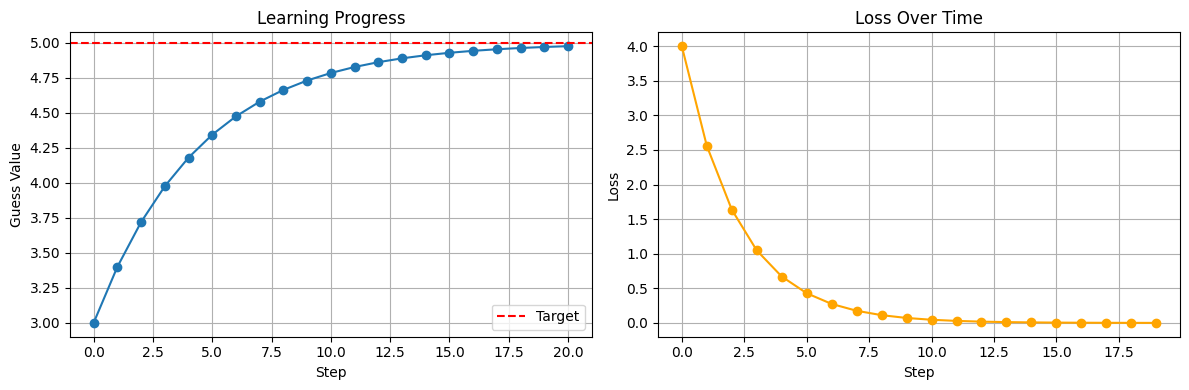

Started at: 3.00
Ended at: 4.9769
Target: 5.0


In [17]:
import torch
import matplotlib.pyplot as plt

guess = torch.tensor(3.0, requires_grad=True)
target = torch.tensor(5.0)
learning_rate = 0.1

guesses = [guess.item()]
losses = []

for step in range(20):  # More steps to see the curve
    loss = (guess - target) ** 2
    losses.append(loss.item())
    
    loss.backward()
    
    with torch.no_grad():
        guess = guess - learning_rate * guess.grad
        guess.requires_grad = True
    
    guesses.append(guess.item())
    guess.grad = None

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(guesses, marker='o')
plt.axhline(y=5.0, color='r', linestyle='--', label='Target')
plt.xlabel('Step')
plt.ylabel('Guess Value')
plt.title('Learning Progress')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses, marker='o', color='orange')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Loss Over Time')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Started at: {guesses[0]:.2f}")
print(f"Ended at: {guesses[-1]:.4f}")
print(f"Target: {target.item()}")

In [20]:
# Challenge: Train a model to learn Y = 2X + 3
# Given X, predict Y
import torch
import matplotlib.pyplot as plt

# The true function is: y = 2*x + 3
# But our model doesn't know this - it has to LEARN it!

def true_function(x):
    return 2 * x + 3

x = torch.tensor(4.0)  # Input
y_true = true_function(x)     # True answer (11.0)

# Our model's parameters (start with random guesses)
weight = torch.tensor(0.5, requires_grad=True)  # Should learn to be 2.0
bias = torch.tensor(0.0, requires_grad=True)    # Should learn to be 3.0

# TODO: Train for 100 steps with learning_rate = 0.01
# At each step:
#   1. Calculate prediction: y_pred = weight * x + bias
#   2. Calculate loss: (y_pred - y_true) ** 2
#   3. Backward pass
#   4. Update weight and bias
#   5. Track loss values for plotting


learning_rate = 0.01

for step in range(100):
    y_pred = weight * x + bias
    loss = (y_pred - y_true) ** 2
    biases.append(bias.item())

    weights = [weight.item()]
    biases = []

    with torch.no_grad():
        weight = weight - learning_rate * weight.grad
        weight.requires_grad = True

        biases.append(bias.item())
        bias.grad = None

        bias.backward()
        
        

# Plot the learning curve
# Final: print what weight and bias converged to

plt.subplot(1, 2, 1)
plt.plot(weights, marker='o')
plt.axhline(y=5.0, color='r', linestyle='--', label='Target')
plt.xlabel('Step')
plt.ylabel('Weight Value')
plt.title('Learning Progress')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(biases, marker='o', color='orange')
plt.xlabel('Step')
plt.ylabel('Bias')
plt.title('Bias Over Time')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Started at: {weights[0]:.2f}")
print(f"Ended at: {weights[-1]:.4f}")
print(f"Target: {target.item()}")

NameError: name 'biases' is not defined

In [21]:
import torch
import matplotlib.pyplot as plt

# The secret function (model doesn't know this!)
def true_function(x):
    return 2 * x + 3

# Test data point
x = torch.tensor(4.0)
y_true = true_function(x)  # = 11.0

print(f"Input: {x}")
print(f"True output: {y_true}")
print(f"\nGoal: Learn that the function is y = 2*x + 3")

Input: 4.0
True output: 11.0

Goal: Learn that the function is y = 2*x + 3


In [27]:
import torch
import matplotlib.pyplot as plt

# The secret function (model doesn't know this!)
def true_function(x):
    return 2 * x + 3

# Test data point
x = torch.tensor(4.0)
y_true = true_function(x)  # = 11.0

print(f"Input: {x}")
print(f"True output: {y_true}")
print(f"\nGoal: Learn that the function is y = 2*x + 3")

# Model parameters (start with bad guesses)
weight = torch.tensor(0.5, requires_grad=True)  # Should become 2.0
bias = torch.tensor(0.0, requires_grad=True)    # Should become 3.0

print(f"Starting weight: {weight.item()}")
print(f"Starting bias: {bias.item()}")

learning_rate = 0.01
num_steps = 100

# Track progress for plotting
weight_history = []
bias_history = []
loss_history = []

for step in range(num_steps):
    # TODO 1: Calculate prediction using current weight and bias
    y_pred =  weight * x + bias
    
    # TODO 2: Calculate loss (squared error)
    loss =  (y_pred - y_true) ** 2
    
    # TODO 3: Compute gradients
    loss.backward()
    
    # TODO 4: Update weight (remember: opposite direction of gradient!)
    with torch.no_grad():
        weight = weight - learning_rate * weight.grad
        weight.requires_grad = True
    
    # TODO 5: Update bias (same way as weight)
    with torch.no_grad():
        bias = bias - learning_rate * bias.grad
        bias.requires_grad = True

    # Clear gradients
    weight.grad = None
    bias.grad = None
    
    # Track progress
    weight_history.append(weight.item())
    bias_history.append(bias.item())
    loss_history.append(loss.item())
    
    # Print every 20 steps
    if (step + 1) % 2 == 0:
        print(f"Step {step+1}: weight={weight.item():.4f}, bias={bias.item():.4f}, loss={loss.item():.4f}")

print(f"\nFinal weight: {weight.item():.4f} (should be 2.0)")
print(f"Final bias: {bias.item():.4f} (should be 3.0)")

Input: 4.0
True output: 11.0

Goal: Learn that the function is y = 2*x + 3
Starting weight: 0.5
Starting bias: 0.0
Step 2: weight=1.6952, bias=0.2988, loss=35.2836
Step 4: weight=2.2158, bias=0.4290, loss=6.6950
Step 6: weight=2.4426, bias=0.4857, loss=1.2704
Step 8: weight=2.5414, bias=0.5104, loss=0.2410
Step 10: weight=2.5844, bias=0.5211, loss=0.0457
Step 12: weight=2.6032, bias=0.5258, loss=0.0087
Step 14: weight=2.6113, bias=0.5278, loss=0.0016
Step 16: weight=2.6149, bias=0.5287, loss=0.0003
Step 18: weight=2.6165, bias=0.5291, loss=0.0001
Step 20: weight=2.6171, bias=0.5293, loss=0.0000
Step 22: weight=2.6174, bias=0.5294, loss=0.0000
Step 24: weight=2.6175, bias=0.5294, loss=0.0000
Step 26: weight=2.6176, bias=0.5294, loss=0.0000
Step 28: weight=2.6176, bias=0.5294, loss=0.0000
Step 30: weight=2.6176, bias=0.5294, loss=0.0000
Step 32: weight=2.6176, bias=0.5294, loss=0.0000
Step 34: weight=2.6176, bias=0.5294, loss=0.0000
Step 36: weight=2.6176, bias=0.5294, loss=0.0000
Step 3

In [30]:
# Challenge: Train a model to learn Y = 2X + 3
# Given X, predict Y

import torch

# The true function is: y = 2*x + 3
# But our model doesn't know this - it has to LEARN it!

x = torch.tensor(4.0)  # Input
y_true = 2 * x + 3     # True answer (11.0)

# Our model's parameters (start with random guesses)
weight = torch.tensor(0.5, requires_grad=True)  # Should learn to be 2.0
bias = torch.tensor(0.0, requires_grad=True)    # Should learn to be 3.0

# TODO: Train for 100 steps with learning_rate = 0.01
# At each step:
#   1. Calculate prediction: y_pred = weight * x + bias
#   2. Calculate loss: (y_pred - y_true) ** 2
#   3. Backward pass
#   4. Update weight and bias
#   5. Track loss values for plotting

# Plot the learning curve
# Final: print what weight and bias converged to
learning_rate = 0.01

y_pred = weight *  x + bias
loss = (y-pred - y_true)** 2

loss.backward()

with torch.no_grad():  # Don't track this update operation
        weight_updated = weight - learning_rate * weight.grad
        weight.requires_grad = True 


with torch.no_grad():  # Don't track this update operation
        bias_updated = bias - learning_rate * bias.grad
        bias.requires_grad = True 

    weight.grad = None
    bias.grad = None
    
    # Track progress
    weight_history.append(weight.item())
    bias_history.append(bias.item())
    loss_history.append(loss.item())
    
    # Print every 20 steps
    if (step + 1) % 20 == 0:
        print(f"Step {step+1}: weight={weight.item():.4f}, bias={bias.item():.4f}, loss={loss.item():.4f}")

print(f"\nFinal weight: {weight.item():.4f} (should be 2.0)")
print(f"Final bias: {bias.item():.4f} (should be 3.0)")







IndentationError: unindent does not match any outer indentation level (<tokenize>, line 42)